# Lab Tasks 

## Task 1

The Python dictionary below stores details of Twitter/X follower relations for a set of 6 users on the platform. 

Each key is a username *A* and the corresponding list indicates the names of other users who follow the user *A*.

Based on this data, construct an appropriate network using NetworkX, and identify: 

- The total number of nodes and edges in the network.
- All edges in the network that are *reciprocated*.

In [1]:
import networkx as nx

In [2]:
follower_data = {'@alice88': ['@amara2000', '@freya_ie', '@sydney'],
    '@amara2000': ['@freya_ie', '@alice88', '@dobrien', '@marcjones'],
    '@dobrien': ['@marcjones', '@alice88'],
    '@freya_ie': ['@sydney'],
    '@marcjones': ['@freya_ie', '@alice88', '@amara2000', '@dobrien'],
    '@sydney': ['@alice88']}

In [3]:
g = nx.DiGraph(follower_data)

In [4]:
g.number_of_edges()

15

In [5]:
g.number_of_nodes()

6

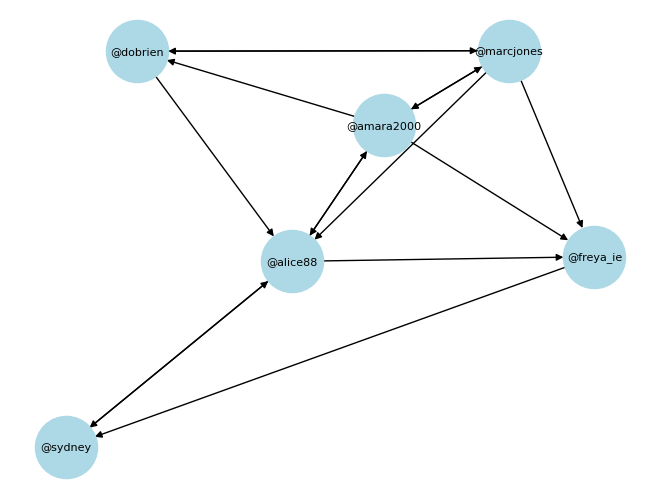

In [6]:
nx.draw(g,
        with_labels=True, 
        node_color="lightblue", 
        node_size=2000, 
        font_color="black", 
        font_size=8)

## Task 2

The Python dictionary below records meeting attendances for team members of a research group across an 8 week period. 

Based on this data, construct an appropriate weighted **co-presence** network, and identify: 

- The total number of nodes and edges in the network.
- The edge(s) with the highest weight in the network.

In [7]:
meeting_data = {'week1': ['bob', 'alice', 'oliver', 'justin'],
    'week2': ['maria', 'tanya', 'justin', 'bob', 'oliver'],
    'week3': ['lara', 'tanya', 'maria', 'justin'],
    'week4': ['justin', 'bob', 'tanya'],
    'week5': ['alice', 'tanya', 'lara', 'bob', 'justin'],
    'week6': ['oliver', 'maria', 'lara'],
    'week7': ['tanya', 'justin', 'bob'],
    'week8': ['maria', 'tanya', 'bob']}

In [8]:
import itertools as it

In [12]:
mg = nx.Graph()

In [13]:
for week in meeting_data:
    for pair in it.combinations(meeting_data.get(week),r=2):
        if mg.has_edge(pair[0], pair[1]):
            data = mg.get_edge_data(pair[0], pair[1])
            mg.add_edge(pair[0], pair[1], weight = data['weight'] + 1)
        else:
            mg.add_edge(pair[0], pair[1], weight = 1)

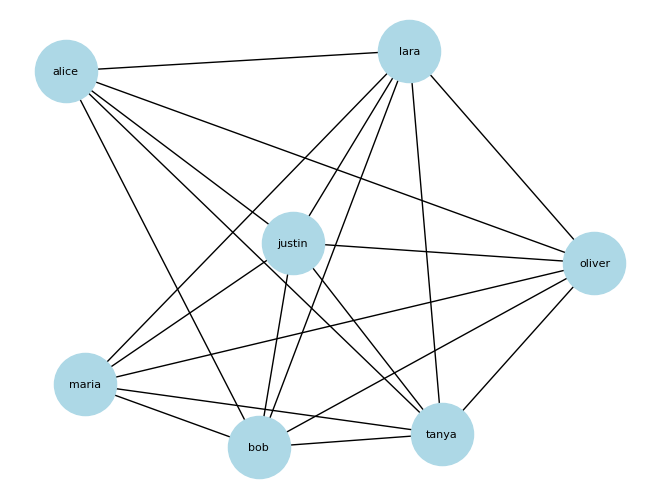

In [14]:
nx.draw(mg,
        with_labels=True, 
        node_color="lightblue", 
        node_size=2000, 
        font_color="black", 
        font_size=8)

{('bob', 'alice'): Text(0.18390957966437838, 0.7283237453025293, '2'),
 ('bob', 'oliver'): Text(-0.5286725297044488, 0.29445719577946505, '2'),
 ('bob', 'justin'): Text(0.07773912747745326, 0.2922678403924659, '5'),
 ('bob', 'maria'): Text(-0.328848613816067, -0.18396934917798702, '2'),
 ('bob', 'tanya'): Text(-0.14232111644062428, 0.09571283395769647, '5'),
 ('bob', 'lara'): Text(0.21845460237333025, -0.08515874549336655, '1'),
 ('alice', 'oliver'): Text(-0.13686545847819098, 0.5661314186677466, '1'),
 ('alice', 'justin'): Text(0.46954238278953286, 0.563949983919243, '2'),
 ('alice', 'tanya'): Text(0.2494891958768568, 0.36737452566069884, '1'),
 ('alice', 'lara'): Text(0.6102609170250379, 0.18651804464611677, '1'),
 ('oliver', 'justin'): Text(-0.2430391213914721, 0.13007909101061133, '2'),
 ('oliver', 'maria'): Text(-0.649622322535405, -0.3461686834761759, '2'),
 ('oliver', 'tanya'): Text(-0.46309544835474303, -0.06649101353815579, '1'),
 ('oliver', 'lara'): Text(-0.10231884616502418,

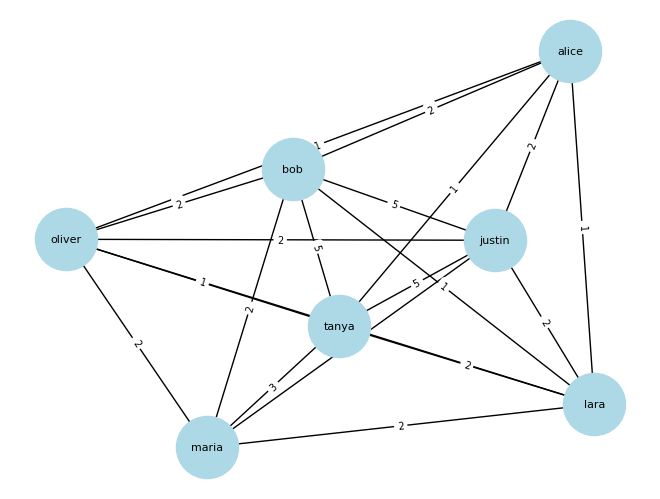

In [15]:
pos = nx.spring_layout(mg, seed=42)

nx.draw(
    mg,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=2000,
    font_color="black",
    font_size=8
)

edge_labels = nx.get_edge_attributes(mg, "weight")
nx.draw_networkx_edge_labels(
    mg,
    pos,
    edge_labels=edge_labels,
    font_size=7
)


In [18]:
mg.number_of_nodes()

7

In [20]:
mg.number_of_edges()

20